# Grid Inspection -- Momentum

Takes a folder of saved backtest results -- one subdirectory per UID, each
written by `runners/run_strats.py` / `runners/run_strats_grid.py`
(`tradebook.csv`, `equity.csv`, `metrics.csv`) -- and gives you:

1. A metrics comparison table across every UID in that folder.
2. The same comparison recomputed under a simulated per-execution slippage
   cost, so you can see how sensitive each parameter combo is to slippage
   before trusting the no-slippage backtest numbers.
3. An equity-curve chart overlaying the top `TOP_N_TO_PLOT` UIDs (ranked by
   `RANK_METRIC`) -- with and without slippage applied.

Point `RESULTS_DIR` (in the Config cell) at whatever grid you want to
inspect -- e.g. `results/momentum` or `results/momentum_indicator`.

This mirrors `notebooks/grid_inspection.ipynb` (the futures version), with
two differences instead of a shared implementation: momentum strategies
trade a basket of symbols rather than one futures contract, so there's no
`get_futures_instrument`/tick-value lookup here -- slippage is modeled as
basis points of each execution's traded dollar value instead of ticks --
and the equity-curve chart is capped to the top N UIDs, since a momentum
grid can have far more combos than are readable on one chart at once.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analytics.metrics import calculate_metrics

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

print("Setup OK")

Setup OK


## Config

`RESULTS_DIR` is any folder containing one subdirectory per UID (each with
`tradebook.csv` / `equity.csv` / `metrics.csv` inside) -- point it at a
single strategy's results folder (e.g. `results/momentum` or
`results/momentum_indicator`).

`SLIPPAGE_BPS` drives the simulated-slippage comparison: every trade
execution in the tradebook (`value` = dollar notional traded, which for a
rebalance already nets a symbol's buy/sell down to one row) is assumed to
cost `SLIPPAGE_BPS` basis points of its own traded value. Set it to `0` to
make the "slippage" scenario identical to the raw one.

`TOP_N_TO_PLOT` / `RANK_METRIC` control the equity-curve chart only -- the
comparison table below always shows every UID in `RESULTS_DIR`; only the
chart is capped, since overlaying 40+ curves on one plot is unreadable.

In [ ]:
# Folder containing one subdirectory per UID -- e.g. the momentum grid
# sweep from runners/run_strats_grid.py.
RESULTS_DIR = PROJECT_ROOT / "results" / "momentum"

# Basis points of adverse price movement assumed on every execution's
# traded dollar value (from the tradebook's "value" column).
SLIPPAGE_BPS = 5.0

# Must match what runners/run_strats.py used when it produced the saved
# metrics.csv/equity.csv (see its save_and_print_results call) so the
# recomputed metrics here stay comparable to the saved ones.
PERIODS_PER_YEAR = 252

# Equity-curve chart only: how many UIDs to overlay, ranked by RANK_METRIC
# (highest first) from the no-slippage scenario.
TOP_N_TO_PLOT = 15


print(f"Results dir:    {RESULTS_DIR}")
print(f"Slippage:       {SLIPPAGE_BPS:g} bps per execution")
print(f"Exists:         {RESULTS_DIR.exists()}")

Results dir:    /Users/mayankjain/Quant/atlas/results/momentum
Slippage:       5 bps per execution
Exists:         True


## Metrics comparison

Loads every UID subdirectory under `RESULTS_DIR`, recomputes metrics from
the saved `equity.csv` both as-is and with `SLIPPAGE_BPS` of simulated
slippage deducted at each execution, and lays them out as one table --
UIDs (plus a no-slippage/slippage scenario tag) on the rows, metrics on
the columns.

Slippage is applied as a running dollar cost
(`SLIPPAGE_BPS/10000 * execution value`, from the tradebook's own `value`
column) subtracted from the equity curve from each execution's timestamp
onward -- so drawdown and Sharpe see the drag when it actually happened,
not just as a haircut on the final number. Metrics are recomputed with
`analytics.metrics.calculate_metrics`, the same function `runners/reporting.py`
uses to build the saved `metrics.csv` files, so the no-slippage row here
should match them.

In [ ]:
_METRIC_COLUMNS = {
    "initial_equity", "final_equity", "total_return", "cagr",
    "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown",
    "calmar_ratio", "max_drawdown_duration_days", "win_rate", "best_day",
    "worst_day", "positive_days", "negative_days", "flat_days", "elapsed_years",
}
_BOOKKEEPING_COLUMNS = {"uid", "strategy", "trade_count"}


def _discover_uid_dirs(results_dir: Path) -> list[Path]:
    """Every immediate subdirectory with a complete saved backtest run.

    Requires equity.csv, tradebook.csv, and metrics.csv specifically
    (not just equity.csv) -- results/ can accumulate leftover
    directories from older/incomplete ad hoc runs that never finished
    writing everything, and this loop reads all three."""
    required = ("equity.csv", "tradebook.csv", "metrics.csv")
    return sorted(
        path for path in results_dir.iterdir()
        if path.is_dir() and all((path / name).exists() for name in required)
    )


def apply_slippage(
    equity: pd.DataFrame,
    tradebook: pd.DataFrame,
    slippage_bps: float,
) -> pd.DataFrame:
    """Deduct a per-execution slippage cost from the equity curve, applied
    cumulatively from each execution's timestamp forward. Cost is
    slippage_bps of that execution's own traded dollar value (tradebook's
    "value" column) -- no per-instrument lookup needed, unlike futures'
    tick-based model."""
    adjusted = equity.copy()
    adjusted["timestamp"] = pd.to_datetime(adjusted["timestamp"])
    adjusted = adjusted.sort_values("timestamp")

    if slippage_bps <= 0 or tradebook.empty:
        return adjusted

    executions = tradebook[["timestamp", "value"]].copy()
    executions["timestamp"] = pd.to_datetime(executions["timestamp"])
    executions = executions.sort_values("timestamp")
    executions["cost"] = executions["value"].abs() * (slippage_bps / 10_000.0)
    executions["cumulative_cost"] = executions["cost"].cumsum()

    adjusted = pd.merge_asof(
        adjusted,
        executions[["timestamp", "cumulative_cost"]],
        on="timestamp",
        direction="backward",
    )
    adjusted["cumulative_cost"] = adjusted["cumulative_cost"].fillna(0.0)
    adjusted["equity"] = adjusted["equity"] - adjusted["cumulative_cost"]
    return adjusted.drop(columns=["cumulative_cost"])


records = []
equity_curves: dict[str, dict[str, pd.DataFrame]] = {}

for uid_dir in _discover_uid_dirs(RESULTS_DIR):
    uid = uid_dir.name
    equity = pd.read_csv(uid_dir / "equity.csv")
    tradebook = pd.read_csv(uid_dir / "tradebook.csv")
    metrics_row = pd.read_csv(uid_dir / "metrics.csv").iloc[0]

    param_columns = {
        col: metrics_row[col]
        for col in metrics_row.index
        if col not in _METRIC_COLUMNS and col not in _BOOKKEEPING_COLUMNS
    }

    raw_equity = equity.copy()
    raw_equity["timestamp"] = pd.to_datetime(raw_equity["timestamp"])
    slipped_equity = apply_slippage(equity, tradebook, SLIPPAGE_BPS)

    equity_curves[uid] = {"no_slippage": raw_equity, "slippage": slipped_equity}

    for scenario, curve in (
        ("no_slippage", raw_equity),
        (f"slippage_{SLIPPAGE_BPS:g}bps", slipped_equity),
    ):
        metrics = calculate_metrics(curve, periods_per_year=PERIODS_PER_YEAR)
        records.append({
            "uid": uid,
            "scenario": scenario,
            "trades": len(tradebook),
            **param_columns,
            **metrics,
        })

comparison = pd.DataFrame(records).set_index(["uid", "scenario"])

print(f"Loaded {len(equity_curves)} UIDs from {RESULTS_DIR}")

display_columns = [
    c for c in (
        list(param_columns.keys()) + [
            "trades", "final_equity", "total_return", "cagr",
            "annualized_volatility", "sharpe_ratio", "sortino_ratio",
            "max_drawdown", "calmar_ratio", "win_rate",
        ]
    )
    if c in comparison.columns
]

comparison[display_columns].sort_values(
    ["scenario", "sharpe_ratio"], ascending=[True, False],
)

Loaded 41 UIDs from /Users/mayankjain/Quant/atlas/results/momentum


,,strategy_type,universe,signal,lookback,rebalance_period,top_n,allocator,rsi_window,rsi_threshold,ma_short_window,ma_long_window,minimum_score,trades,final_equity,total_return,cagr,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate
uid,scenario,,,,,,,,,,,,,,,,,,,,,,
momentum__u=nasdaq100__sig=price__lb=90__rb=monthly__n=15__alloc=score,no_slippage,momentum,nasdaq100,price,90,monthly,15,score,14,50.0,40,100,0.0,6439,3.114276e+08,3113.276340,0.354181,0.307429,1.143092,1.112059,-0.561575,0.630693,0.551042
momentum__u=nasdaq100__sig=price__lb=90__rb=monthly__n=20__alloc=score,no_slippage,momentum,nasdaq100,price,90,monthly,20,score,14,50.0,40,100,0.0,8275,2.064166e+08,2063.165617,0.333350,0.293264,1.130772,1.090919,-0.555904,0.599655,0.554340
momentum__u=nasdaq100__sig=price__lb=90__rb=monthly__n=10__alloc=score,no_slippage,momentum,nasdaq100,price,90,monthly,10,score,14,50.0,40,100,0.0,4442,4.040132e+08,4039.131634,0.367533,0.332137,1.111503,1.090996,-0.577626,0.636281,0.546994
momentum__u=nasdaq100__sig=price__lb=60__rb=quarterly__n=10__alloc=score,no_slippage,momentum,nasdaq100,price,60,quarterly,10,score,14,50.0,40,100,0.0,1889,4.216596e+08,4215.596269,0.369738,0.337470,1.103996,1.077570,-0.661043,0.559325,0.552241
momentum__u=nasdaq100__sig=price__lb=60__rb=monthly__n=10__alloc=score,no_slippage,momentum,nasdaq100,price,60,monthly,10,score,14,50.0,40,100,0.0,4726,3.207109e+08,3206.108659,0.355682,0.330109,1.089631,1.077196,-0.563813,0.630851,0.546245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
momentum__u=nasdaq100__sig=price__lb=252__rb=monthly__n=20__alloc=score,slippage_5bps,momentum,nasdaq100,price,252,monthly,20,score,14,50.0,40,100,0.0,7430,9.114223e+07,910.878240,0.292916,0.321032,0.963664,0.924108,-0.600665,0.487653,0.552331
momentum__u=nasdaq100__sig=price__lb=252__rb=quarterly__n=5__alloc=score,slippage_5bps,momentum,nasdaq100,price,252,quarterly,5,score,14,50.0,40,100,0.0,783,2.985359e+08,2985.852227,0.352051,0.414770,0.937030,0.934593,-0.860667,0.409044,0.540249
momentum__u=nasdaq100__sig=price__lb=252__rb=quarterly__n=10__alloc=score,slippage_5bps,momentum,nasdaq100,price,252,quarterly,10,score,14,50.0,40,100,0.0,1510,1.317039e+08,1316.697488,0.310982,0.364369,0.927903,0.911477,-0.752370,0.413337,0.544146


## Equity curves -- top UIDs by `RANK_METRIC`, with and without slippage

Ranked from the no-slippage scenario; capped to `TOP_N_TO_PLOT` so the
chart stays readable.

In [5]:
RANK_METRIC = "cagr"

Plotting top 15 of 41 UIDs by cagr:
  0.432  momentum__u=nasdaq100__sig=price__lb=180__rb=quarterly__n=5__alloc=score
  0.417  momentum__u=nasdaq100__sig=price__lb=90__rb=quarterly__n=5__alloc=score
  0.406  momentum__u=nasdaq100__sig=price__lb=126__rb=quarterly__n=5__alloc=score
  0.405  momentum__u=nasdaq100__sig=price__lb=60__rb=quarterly__n=5__alloc=score
  0.402  momentum__u=nasdaq100__sig=price__lb=126__rb=monthly__n=5__alloc=score
  0.393  momentum__u=nasdaq100__sig=price__lb=60__rb=monthly__n=5__alloc=score
  0.385  momentum__u=nasdaq100__sig=price__lb=90__rb=monthly__n=5__alloc=score
  0.385  momentum__u=nasdaq100__sig=price__lb=180__rb=monthly__n=5__alloc=score
  0.382  momentum__u=nasdaq100__sig=price__lb=252__rb=monthly__n=5__alloc=score
  0.370  momentum__u=nasdaq100__sig=price__lb=60__rb=quarterly__n=10__alloc=score
  0.368  momentum__u=nasdaq100__sig=price__lb=90__rb=monthly__n=10__alloc=score
  0.364  momentum__u=nasdaq100__sig=price__lb=126__rb=monthly__n=10__alloc=sco

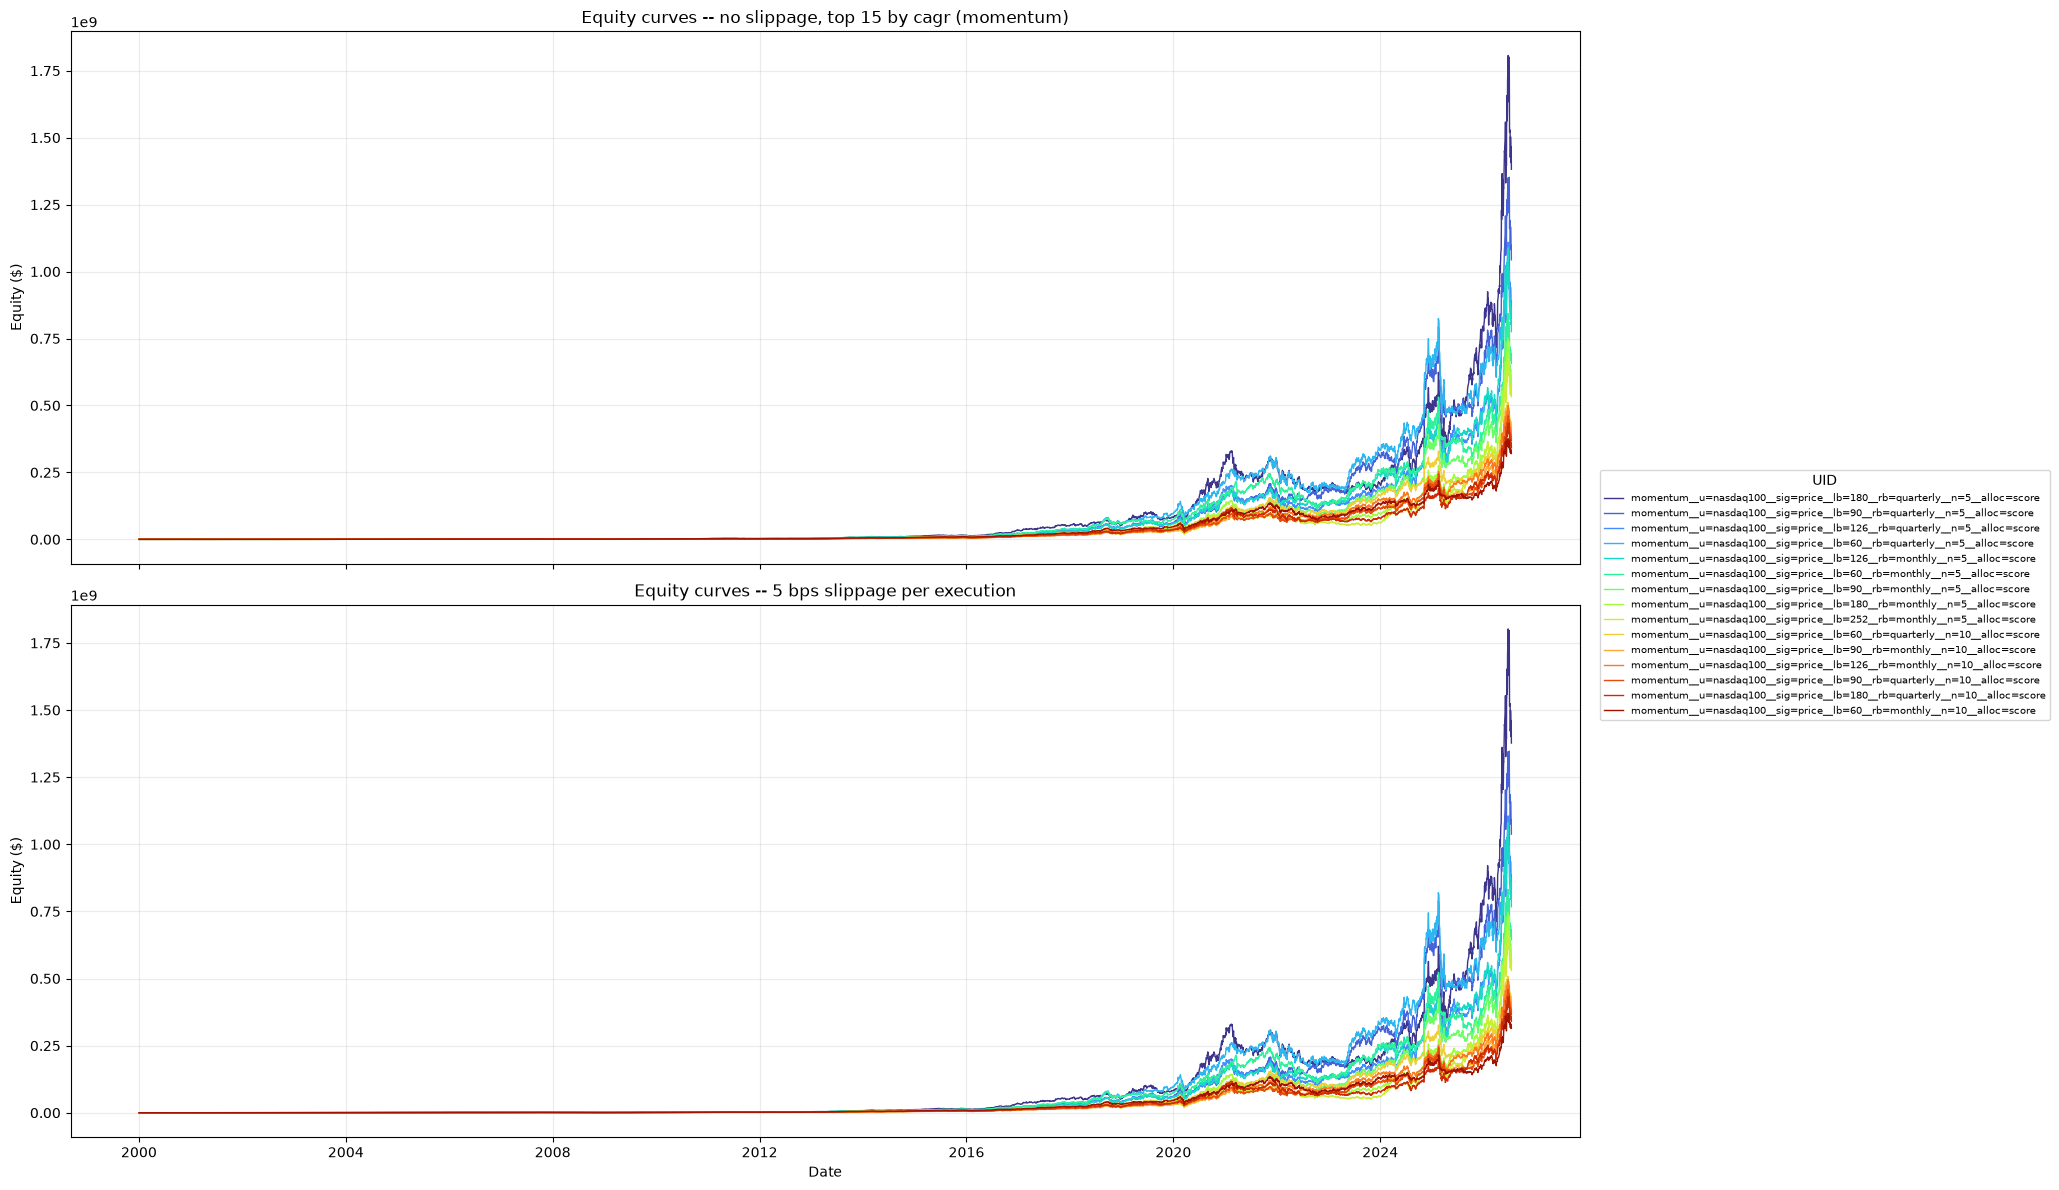

In [6]:
no_slippage_scenario = comparison.xs("no_slippage", level="scenario")
top_uids = (
    no_slippage_scenario[RANK_METRIC]
    .dropna()
    .sort_values(ascending=False)
    .head(TOP_N_TO_PLOT)
    .index
    .tolist()
)

print(f"Plotting top {len(top_uids)} of {len(equity_curves)} UIDs by {RANK_METRIC}:")
for uid in top_uids:
    print(f"  {no_slippage_scenario.loc[uid, RANK_METRIC]:.3f}  {uid}")

colors = plt.cm.turbo(np.linspace(0.05, 0.95, max(len(top_uids), 1)))
color_by_uid = dict(zip(top_uids, colors))

figure, (raw_axis, slip_axis) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 12),
    sharex=True,
)

for uid in top_uids:
    color = color_by_uid[uid]

    raw = equity_curves[uid]["no_slippage"]
    raw_axis.plot(raw["timestamp"], raw["equity"], label=uid, linewidth=1.0, color=color)

    slipped = equity_curves[uid]["slippage"]
    slip_axis.plot(slipped["timestamp"], slipped["equity"], label=uid, linewidth=1.0, color=color)

raw_axis.set_title(f"Equity curves -- no slippage, top {len(top_uids)} by {RANK_METRIC} ({RESULTS_DIR.name})")
raw_axis.set_ylabel("Equity ($)")
raw_axis.grid(alpha=0.25)

slip_axis.set_title(f"Equity curves -- {SLIPPAGE_BPS:g} bps slippage per execution")
slip_axis.set_ylabel("Equity ($)")
slip_axis.set_xlabel("Date")
slip_axis.grid(alpha=0.25)

handles, labels = raw_axis.get_legend_handles_labels()
figure.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=7,
    ncol=1,
    title="UID",
)

figure.tight_layout()
plt.show()